### Estimate ten year risk-factor across cities 
- Likelihood of a mass-shooting event
- Potential number of mass-shooting related fatalities over next ten years
    - City-level and country-level

In [1]:
# 1. Sample params from VBMC posterior
# 2. For each city, run conditional sampling to get event size distribution
# 3. Estimate risk factors from event size distribution

In [3]:
import jax.random as jrand
import jax.numpy as jnp
import pickle
import numpy as np
from gvabm.city_data import subsampled_city_data, subsampled_city_data_names, subsample_weights
import numpy as np

with open('/home/andrew/abm_violence/paper_code/data/city_sample_stats.pkl', 'rb') as f:
    city_stat_dict = pickle.load(f)

city_ids = ['_'.join(name) for name in subsampled_city_data_names]
data_tensor = np.stack([city_stat_dict[city_id] for city_id in city_ids], axis=0)
city_mean_val = np.nanmean(data_tensor, axis=1)
propensity = city_mean_val[:, 0]
expected_event_size = city_mean_val[:, 1]
event_prob = city_mean_val[:, 2]
p_loc = city_mean_val[:, 3]
p_weapon = city_mean_val[:, 4]
p_high_weapon = city_mean_val[:, 5]
#City list x ([propensity, expected_event_size, p_event, p_loc, p_weapon, p_high_weapon, access_count])

In [4]:
first_key = list(city_stat_dict.keys())[0]
print(f"Data shape for first city ({first_key}): {city_stat_dict[first_key].shape}")
data = city_stat_dict[first_key]  # Show first 5 samples for the first city

Data shape for first city (G130013093390_2020): (500, 7)


In [5]:
city_event_probs = []
city_ev = []

for city_name in subsampled_city_data_names:
    city_id = '_'.join(city_name)
    data = city_stat_dict[city_id]
    propensity, expected_event_size, p_event, p_loc, p_weapon, p_high_weapon, access_count = data.T
    event_prob = np.mean(p_event)
    city_event_probs.append(event_prob)
    expected_severity = np.nanmean(expected_event_size)
    city_ev.append(expected_severity)
city_event_probs = np.array(city_event_probs) #probability of mass shooting occurring conditional on shooter
city_ev = np.array(city_ev) #expected severity of mass shooting conditional on shooter

In [6]:
data_tensor = np.stack([city_stat_dict[city_id] for city_id in city_ids], axis=0)
city_mean_val = np.nanmean(data_tensor, axis=1)
propensity = city_mean_val[:, 0]
expected_event_size = city_mean_val[:, 1]
event_prob = city_mean_val[:, 2]
p_loc = city_mean_val[:, 3]
p_weapon = city_mean_val[:, 4]
p_high_weapon = city_mean_val[:, 5]

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.hist(p_weapon, weights=subsample_weights, bins=np.linspace(0, 0.4, 30), density=True, alpha=0.4, color='green', edgecolor='green', label='Histogram')
ax.hist(p_high_weapon, weights=subsample_weights, bins=np.linspace(0, 0.4, 30), density=True, alpha=0.4, color='red', edgecolor='red', label='Histogram')
fig.show()

NameError: name 'plt' is not defined

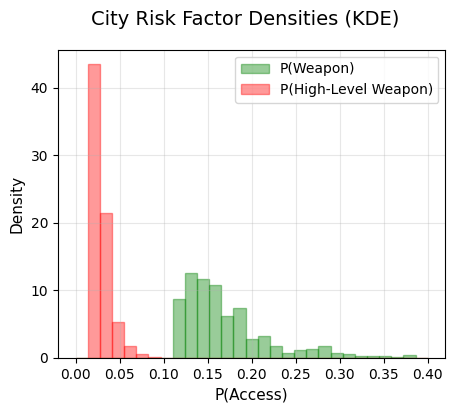

In [100]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
# Generate kde density plots for p_loc, p_weapon, and p_high_weapon

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
# kde_p_weapon = gaussian_kde(p_weapon, weights=subsample_weights)
# x_range_weapon = np.linspace(0, 0.4, 200)
# density_weapon = kde_p_weapon(x_range_weapon)
# ax.plot(x_range_weapon, density_weapon, color='green', label='P(Weapon)')
# ax.fill_between(x_range_weapon, density_weapon, alpha=0.3, color='green')
# ax.grid(True, alpha=0.3)
# kde_p_high_weapon = gaussian_kde(p_high_weapon, weights=subsample_weights)
# # x_range_high_weapon = np.linspace(0, 0.5, 200)
# density_high_weapon = kde_p_high_weapon(x_range_weapon)
# ax.plot(x_range_weapon, density_high_weapon, color='red', label='P(High-Level Weapon)')
# ax.fill_between(x_range_weapon, density_high_weapon, alpha=0.3, color='red')
ax.hist(p_weapon, weights=subsample_weights, bins=np.linspace(0, 0.4, 30), density=True, 
        alpha=0.4, color='green', edgecolor='green', label='P(Weapon)')
ax.hist(p_high_weapon, weights=subsample_weights, bins=np.linspace(0, 0.4, 30), density=True, 
        alpha=0.4, color='red', edgecolor='red', label='P(High-Level Weapon)')
ax.set_xlabel('P(Access)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
fig.suptitle('City Risk Factor Densities (KDE)', fontsize=14)
plt.savefig('/home/andrew/abm_violence/paper_code/images/weapon_access_kde.png', 
            dpi=300, bbox_inches='tight')

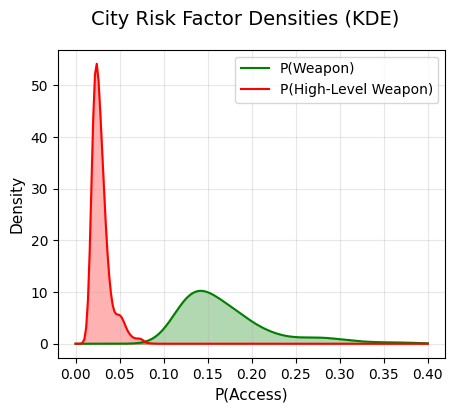

In [ ]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
# Generate kde density plots for p_loc, p_weapon, and p_high_weapon

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
kde_p_weapon = gaussian_kde(p_weapon, weights=subsample_weights)
x_range_weapon = np.linspace(0, 0.4, 200)
density_weapon = kde_p_weapon(x_range_weapon)
# ax.plot(x_range_weapon, density_weapon, color='green', label='P(Weapon)')
# ax.fill_between(x_range_weapon, density_weapon, alpha=0.3, color='green')
ax.grid(True, alpha=0.3)
kde_p_high_weapon = gaussian_kde(p_high_weapon, weights=subsample_weights)
# x_range_high_weapon = np.linspace(0, 0.5, 200)
density_high_weapon = kde_p_high_weapon(x_range_weapon)
ax.plot(x_range_weapon, density_high_weapon, color='red', label='P(High-Level Weapon)')
ax.fill_between(x_range_weapon, density_high_weapon, alpha=0.3, color='red')
ax.set_xlabel('P(Access)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
fig.suptitle('City Risk Factor Densities (KDE)', fontsize=14)
plt.savefig('/home/andrew/abm_violence/paper_code/images/weapon_access_kde.png', 
            dpi=300, bbox_inches='tight')

In [54]:
fatality_rate_l = []
for city_name, city_data in zip(subsampled_city_data_names, subsampled_city_data):
    city_id = '_'.join(city_name)
    population = city_data['params'].population
    sample_data = city_stat_dict[city_id]
    propensity, expected_event_size, p_event, p_loc, p_weapon, p_high_weapon, access_count = sample_data.T
    sample_severity = expected_event_size
    fatality_rate = sample_severity * propensity * 10 * population
    fatality_rate = np.nanmean(fatality_rate)
    fatality_rate_l.append(fatality_rate)
fatality_rate_l = np.array(fatality_rate_l) #Expected fatalities per 10 years in the city
# Compute per-person fatality rate
per_person_fatality_rate_l = fatality_rate_l / np.array([city_data['params'].population for city_data in subsampled_city_data])

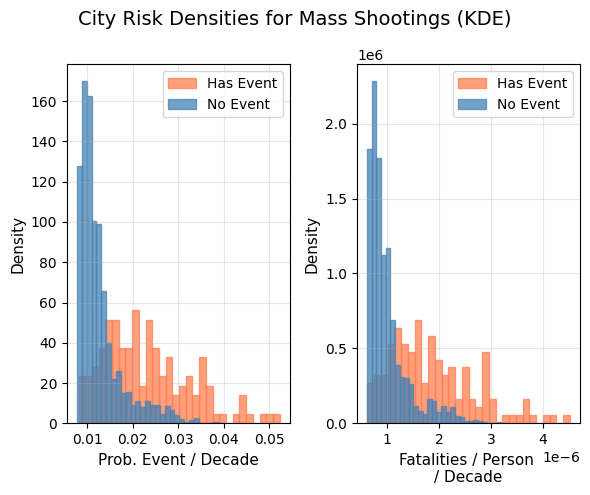

In [103]:
from gvabm.city_data import subsample_weights
import matplotlib.pyplot as plt
has_event = np.array([len(c['events']) > 0 for c in subsampled_city_data])
from gvabm.city_data import subsample_weights
from scipy.stats import gaussian_kde

# Create KDE plots for event probabilities and expected severity
fig, ax = plt.subplots(1, 2, figsize=(6, 5))

kde_event_prob_has = gaussian_kde(city_event_probs[has_event], 
                                   weights=subsample_weights[has_event])
x_range_prob = np.linspace(0, 0.1, 200)
density_has_prob = kde_event_prob_has(x_range_prob)

kde_event_prob_no = gaussian_kde(city_event_probs[~has_event], 
                                 weights=subsample_weights[~has_event])
density_no_prob = kde_event_prob_no(x_range_prob)

# ax[0].plot(x_range_prob, density_has_prob, linewidth=2.5, label='Has Event', color='steelblue')
# ax[0].fill_between(x_range_prob, density_has_prob, alpha=0.3, color='steelblue')
# ax[0].plot(x_range_prob, density_no_prob, linewidth=2.5, label='No Event', color='coral')
# ax[0].fill_between(x_range_prob, density_no_prob, alpha=0.3, color='coral')

ax[0].hist(city_event_probs[has_event], weights=subsample_weights[has_event], 
             bins=30, density=True, alpha=0.75, 
             color='coral', edgecolor='coral', label='Has Event')
ax[0].hist(city_event_probs[~has_event], weights=subsample_weights[~has_event], 
             bins=30, density=True, alpha=0.75,
              color='steelblue', edgecolor='steelblue', label='No Event')


# ax[0].set_title('Risk Rate by City (KDE)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Prob. Event / Decade', fontsize=11)
ax[0].set_ylabel('Density', fontsize=11)
ax[0].legend(fontsize=10)
ax[0].grid(True, alpha=0.3)

# Plot 2: Expected Event Severity using KDE
# Cities with events
kde_ev_has = gaussian_kde(per_person_fatality_rate_l[has_event], 
                         weights=subsample_weights[has_event])
x_range_ev = np.linspace(0, per_person_fatality_rate_l.max(), 200)
density_has_ev = kde_ev_has(x_range_ev)

# Cities without events
kde_ev_no = gaussian_kde(per_person_fatality_rate_l[~has_event], 
                        weights=subsample_weights[~has_event])
density_no_ev = kde_ev_no(x_range_ev)

# ax[1].plot(x_range_ev, density_has_ev, linewidth=2.5, label='Has Event', color='steelblue')
# ax[1].fill_between(x_range_ev, density_has_ev, alpha=0.3, color='steelblue')
# ax[1].plot(x_range_ev, density_no_ev, linewidth=2.5, label='No Event', color='coral')
# ax[1].fill_between(x_range_ev, density_no_ev, alpha=0.3, color='coral')

ax[1].hist(per_person_fatality_rate_l[has_event], weights=subsample_weights[has_event], 
             bins=30, density=True, alpha=0.75, 
             color='coral', edgecolor='coral', label='Has Event')
ax[1].hist(per_person_fatality_rate_l[~has_event], weights=subsample_weights[~has_event], 
             bins=30, density=True, alpha=0.75,
              color='steelblue', edgecolor='steelblue', label='No Event')


# ax[1].set_title('Fatalities / Person / Decade', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Fatalities / Person \n/ Decade', fontsize=11)
ax[1].set_ylabel('Density', fontsize=11)
ax[1].legend(fontsize=10)
ax[1].grid(True, alpha=0.3)

fig.suptitle('City Risk Densities for Mass Shootings (KDE)', fontsize=14)

plt.tight_layout()
plt.savefig('/home/andrew/abm_violence/paper_code/images/city_risk_factors_kde.png', 
            dpi=300, bbox_inches='tight')
plt.show()


In [105]:
subsampled_city_data_id = ['_'.join(name) for name in subsampled_city_data_names]

In [ ]:
#Get the indices for the top 3 highest values of per_person_fatality_rate
top_k_indices = np.argsort(per_person_fatality_rate)[-12:][::-1]
top_k_cities = [(subsampled_city_data_id[i], per_person_fatality_rate[i]) for i in top_k_indices]
city_data_dict = {name: data for name, data in zip(subsampled_city_data_id, subsampled_city_data)}
print("\nTop K Cities by Risk Rate (/person):")
for city, rate in top_k_cities:
    print(f"  {city}: {rate:.6f}")
    print(city_data_dict[city]['params'], len(city_data_dict[city]['events']))

In [109]:
subsampled_city_data[0]

{'events': [EventOutcome(year=2024, fatalities=4, injured=-1, total_victims=-1, population=29492.0, population_density=250.1092680341783)],
 'params': CityParams(year=2024, population=29492.0, population_density=250.1092680341783, arm_count=239.0, arm_density=0.12178343949044586),
 'name': ('Georgia', 'Barrow County')}

In [112]:


top_k_indices = np.argsort(city_event_probs)[-12:][::-1]
top_k_cities = [(subsampled_city_data_id[i], city_event_probs[i], subsampled_city_data[i]) for i in top_k_indices]
city_data_dict = {name: data for name, data in zip(subsampled_city_data_id, subsampled_city_data)}
print("\nTop 12 Cities by Event Probability:")
for city, prob, sub in top_k_cities:
    city_hr_name = sub['name']
    print(f"  {city}: {prob:.6f}")
    print(city_hr_name, len(city_data_dict[city]['events']))
    print(city_data_dict[city]['params'])


Top 12 Cities by Event Probability:
  G480121090637_1990: 0.052304
('Texas', 'Denton County') 1
CityParams(year=1984, population=58907.61, population_density=668.2026991130296, arm_count=887.0000000000001, arm_density=0.4519745222929936)
  G480113093682_2020: 0.049781
('Texas', 'Dallas County') 1
CityParams(year=2016, population=1003311.17, population_density=926.5868113803868, arm_count=765.0000000000001, arm_density=0.38980891719745225)
  G480085093065_2020: 0.047963
('Texas', 'Collin County') 1
CityParams(year=2023, population=597257.06, population_density=1209.3263090120197, arm_count=678.0, arm_density=0.34547770700636943)
  G080005093382_2010: 0.045524
('Colorado', 'Arapahoe County') 1
CityParams(year=2012, population=360758.0, population_density=1784.065029145091, arm_count=577.0, arm_density=0.2940127388535032)
  G080005093382_1990: 0.044116
('Colorado', 'Arapahoe County') 1
CityParams(year=1993, population=224037.04, population_density=1107.9356474345127, arm_count=575.0, arm

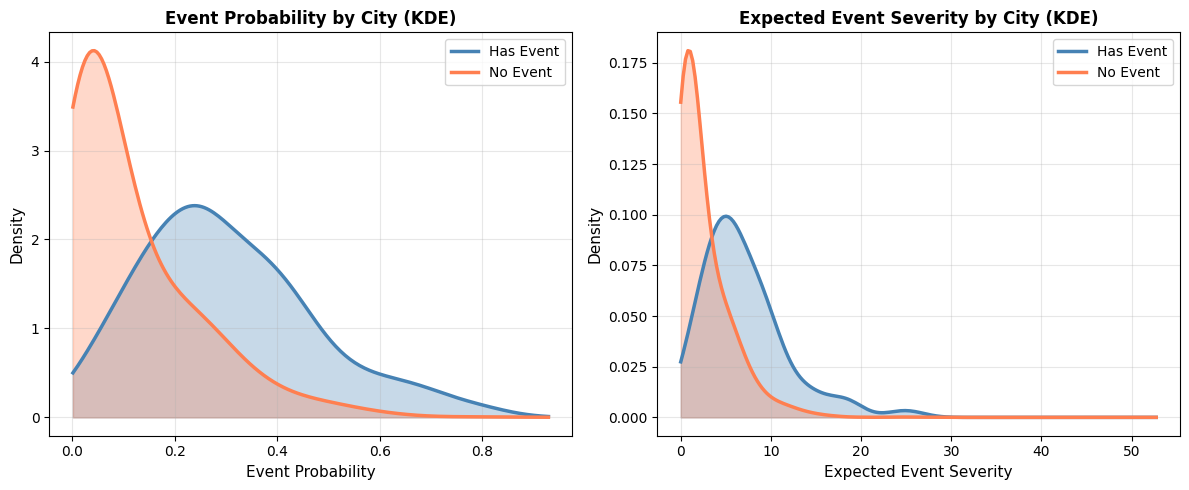


Event Probability Statistics:
  Has Event:  Mean=0.3017, Median=0.2720
  No Event:   Mean=0.1130, Median=0.2020

Expected Severity Statistics:
  Has Event:  Mean=7.0048, Median=5.8937
  No Event:   Mean=2.4764, Median=4.3089


In [6]:


# Create KDE plots for event probabilities and expected severity
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Event Probability by City using KDE
# Cities with events
kde_event_prob_has = gaussian_kde(city_event_probs[has_event], 
                                   weights=subsample_weights[has_event])
x_range_prob = np.linspace(city_event_probs.min(), city_event_probs.max(), 200)
density_has_prob = kde_event_prob_has(x_range_prob)

# Cities without events
kde_event_prob_no = gaussian_kde(city_event_probs[~has_event], 
                                 weights=subsample_weights[~has_event])
density_no_prob = kde_event_prob_no(x_range_prob)

ax[0].plot(x_range_prob, density_has_prob, linewidth=2.5, label='Has Event', color='steelblue')
ax[0].fill_between(x_range_prob, density_has_prob, alpha=0.3, color='steelblue')
ax[0].plot(x_range_prob, density_no_prob, linewidth=2.5, label='No Event', color='coral')
ax[0].fill_between(x_range_prob, density_no_prob, alpha=0.3, color='coral')

ax[0].set_title('Event Probability by City (KDE)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Event Probability', fontsize=11)
ax[0].set_ylabel('Density', fontsize=11)
ax[0].legend(fontsize=10)
ax[0].grid(True, alpha=0.3)

# Plot 2: Expected Event Severity using KDE
# Cities with events
kde_ev_has = gaussian_kde(city_ev[has_event], 
                         weights=subsample_weights[has_event])
x_range_ev = np.linspace(city_ev.min(), city_ev.max(), 200)
density_has_ev = kde_ev_has(x_range_ev)

# Cities without events
kde_ev_no = gaussian_kde(city_ev[~has_event], 
                        weights=subsample_weights[~has_event])
density_no_ev = kde_ev_no(x_range_ev)

ax[1].plot(x_range_ev, density_has_ev, linewidth=2.5, label='Has Event', color='steelblue')
ax[1].fill_between(x_range_ev, density_has_ev, alpha=0.3, color='steelblue')
ax[1].plot(x_range_ev, density_no_ev, linewidth=2.5, label='No Event', color='coral')
ax[1].fill_between(x_range_ev, density_no_ev, alpha=0.3, color='coral')

ax[1].set_title('Expected Event Severity by City (KDE)', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Expected Event Severity', fontsize=11)
ax[1].set_ylabel('Density', fontsize=11)
ax[1].legend(fontsize=10)
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/andrew/abm_violence/paper_code/images/city_risk_factors_kde.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nEvent Probability Statistics:")
print(f"  Has Event:  Mean={np.average(city_event_probs[has_event], weights=subsample_weights[has_event]):.4f}, "
      f"Median={np.median(city_event_probs[has_event]):.4f}")
print(f"  No Event:   Mean={np.average(city_event_probs[~has_event], weights=subsample_weights[~has_event]):.4f}, "
      f"Median={np.median(city_event_probs[~has_event]):.4f}")

print("\nExpected Severity Statistics:")
print(f"  Has Event:  Mean={np.average(city_ev[has_event], weights=subsample_weights[has_event]):.4f}, "
      f"Median={np.median(city_ev[has_event]):.4f}")
print(f"  No Event:   Mean={np.average(city_ev[~has_event], weights=subsample_weights[~has_event]):.4f}, "
      f"Median={np.median(city_ev[~has_event]):.4f}")



Top 3 Cities by Risk Rate (/person):
  MANHATTAN, NEW_YORK: 0.000009
CityParams(population=1694263, population_density=28653.9, arm_count=57.00000000000001, arm_density=0.029044585987261146) 0
  BROOKLYN, NEW_YORK: 0.000006
CityParams(population=2736074, population_density=15200.5, arm_count=46.00000000000001, arm_density=0.023439490445859874) 0
  BRONX, NEW_YORK: 0.000006
CityParams(population=1472654, population_density=13356.3, arm_count=61.0, arm_density=0.0310828025477707) 0
  QUEENS, NEW_YORK: 0.000004
CityParams(population=2405464, population_density=8503.7, arm_count=49.0, arm_density=0.024968152866242037) 0
  JERSEY_CITY, NEW_JERSEY: 0.000004
CityParams(population=289691.0, population_density=7584.1, arm_count=54.0, arm_density=0.027515923566878982) 1
  HUNTINGTON_PARK, CALIFORNIA: 0.000004
CityParams(population=53658, population_density=6889.0, arm_count=105.0, arm_density=0.0535031847133758) 0
  SAN_FRANCISCO, CALIFORNIA: 0.000004
CityParams(population=3364862.0, population

In [44]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve, auc
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
# Predictive performance for event probability

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

has_event = np.array([len(d['events']) > 0 for d in subsampled_city_data])
param_mat = np.array([d['params'] for d in subsampled_city_data])
event_severity = np.array([d['events'][0][1] if len(d['events']) > 0 else 0 for d in subsampled_city_data])
population_density = param_mat[:, 1]
arm_density = param_mat[:, 3]
# pop = param_mat[:, 0]

X = np.vstack([population_density, arm_density]).T
y = has_event.astype(int)
model = make_pipeline(StandardScaler(), LogisticRegression())
model.fit(X, y, logisticregression__sample_weight=subsample_weights)
y_pred_prob = model.predict_proba(X)[:, 1]
roc_auc = roc_auc_score(y, y_pred_prob, sample_weight=subsample_weights)
print(f"Logistic Regression ROC AUC: {roc_auc:.4f}")

Logistic Regression ROC AUC: 0.8176


In [47]:
print(model.named_steps['logisticregression'].coef_)

[[0.47910348 0.61657301]]


ROC AUC (Event Probability): 0.8377


/home/andrew/anaconda3/envs/gvabm/lib/python3.10/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/home/andrew/anaconda3/envs/gvabm/lib/python3.10/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


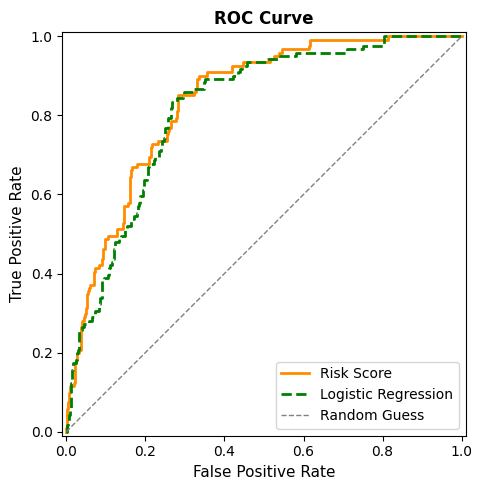

In [46]:
y_true = has_event.astype(int)
y_scores_prob = city_event_probs
y_scores_risk = fatality_rate_l
# ROC AUC for event probability
roc_auc_prob = roc_auc_score(y_true, y_scores_prob, sample_weight=subsample_weights)
print(f"ROC AUC (Event Probability): {roc_auc_prob:.4f}")
# roc_auc_risk = roc_auc_score(y_true, y_scores_risk, sample_weight=subsample_weights)
# print(f"ROC AUC (Risk Score): {roc_auc_risk:.4f}")

# Plot ROC and Precision-Recall curves for event probability
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
# RocCurveDisplay.from_predictions(y_true, y_scores_prob, sample_weight=subsample_weights,
#                                  ax=ax, color='navy', lw=2)
RocCurveDisplay.from_predictions(y_true, y_scores_prob, sample_weight=subsample_weights,
                                 ax=ax, color='darkorange', lw=2)
RocCurveDisplay.from_estimator(model, X, y_true, sample_weight=subsample_weights,
                                 ax=ax, color='green', lw=2, linestyle='--')

ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(['Risk Score', 'Logistic Regression', 'Random Guess'], loc='lower right')

ax.set_title('ROC Curve', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/andrew/abm_violence/paper_code/images/event_probability_roc_pr.png', 
            dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
#Train a logistic regression model to predict event occurrence from population density and arm density

Logistic Regression ROC AUC: 0.8495


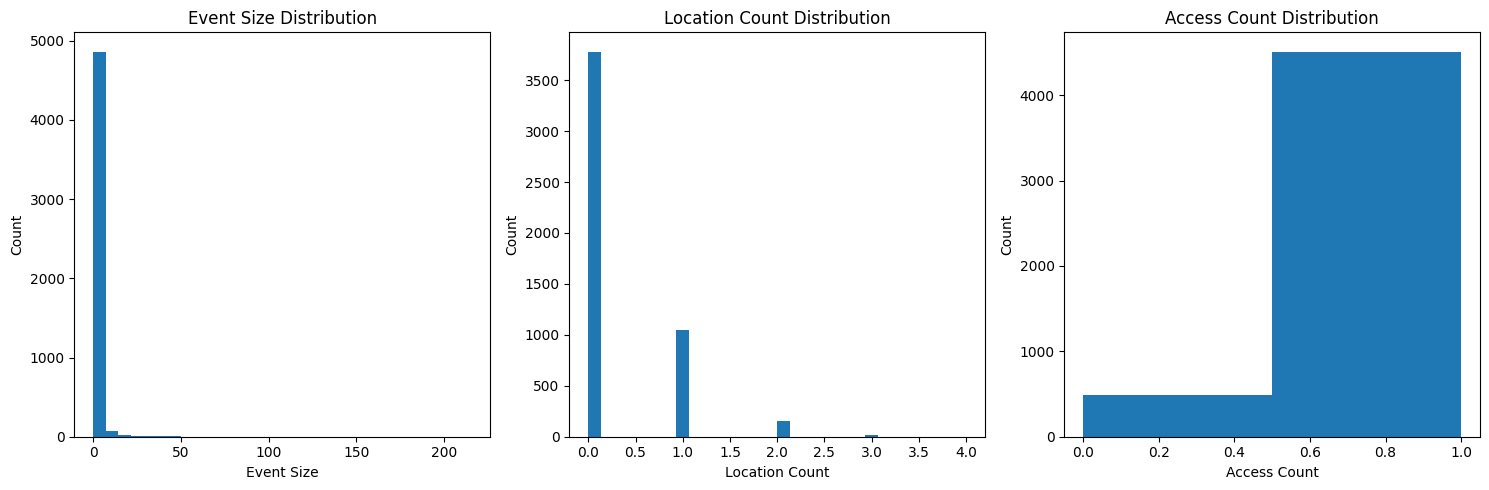

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].hist(sample_data[0], bins=30)
axes[0].set_title("Event Size Distribution")
axes[0].set_xlabel("Event Size")
axes[0].set_ylabel("Count")
axes[1].hist(sample_data[1], bins=30)
axes[1].set_title("Location Count Distribution")
axes[1].set_xlabel("Location Count")
axes[1].set_ylabel("Count")
axes[2].hist(sample_data[2].astype(float), bins=2)
axes[2].set_title("Access Count Distribution")
axes[2].set_xlabel("Access Count")
axes[2].set_ylabel("Count")
plt.tight_layout()
plt.show()

In [5]:
samples, _ = vp.sample(10)
for sample in samples:
    sample_trans = param_distr.transform_sample(sample)
    general_params = param_distr.to_data(sample_trans)
    print(general_params)
    break


GeneralParams(propensity=Array(1.4729115e-08, dtype=float32), walk_radius=Array(52.247498, dtype=float32), arm_bias=Array(2.4707997, dtype=float32), arm_weight=Array(2.7625942, dtype=float32), atrisk_gathering_rate=Array(6.993932e-05, dtype=float32))
